# ALS-U 7.0.1 COSMIC-U model
awojdyla@lbl.gov, Aug 


- you need to have serial distances
- you need to have a point source
- you need to remove tilt after grating 


## code straight from the simulation

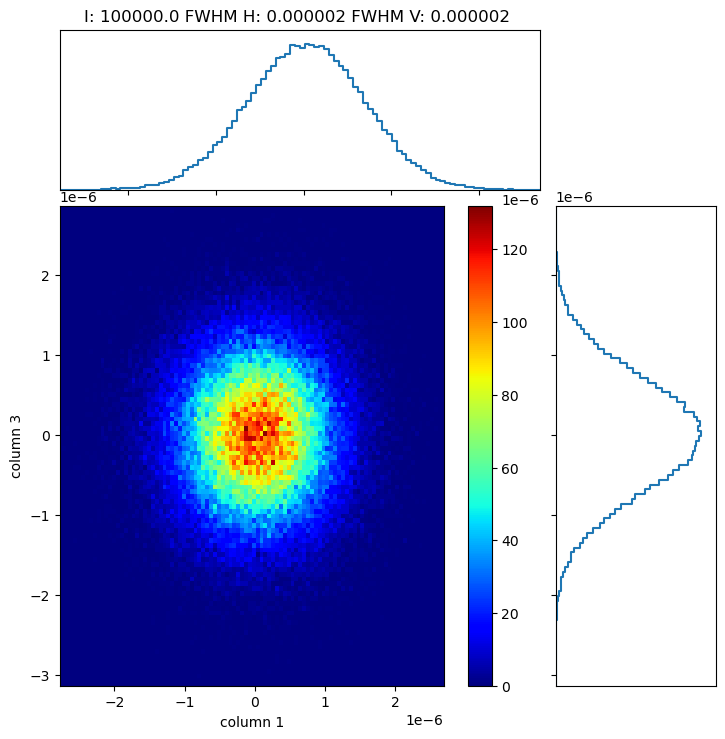

(<Figure size 800x800 with 4 Axes>,
 <Axes: xlabel='column 1', ylabel='column 3'>,
 <Axes: title={'center': 'I: 100000.0 FWHM H: 0.000002 FWHM V: 0.000002 '}>,
 <Axes: >)

In [17]:
import numpy as np

def run_beamline():
    footprint = None
    import numpy as np
    from dabax.dabax_xraylib import DabaxXraylib
    from shadow4.beamline.s4_beamline import S4Beamline
    
    beamline = S4Beamline()
    
    #
    #
    #
    from shadow4.sources.source_geometrical.source_geometrical import SourceGeometrical
    light_source = SourceGeometrical(name='ALS-U COSMIC E=1keV (5)', nrays=100000, seed=0)
    light_source.set_spatial_type_gaussian(sigma_h=0,sigma_v=0)
    light_source.set_depth_distribution_off()
    light_source.set_angular_distribution_gaussian(sigdix=1.9e-05,sigdiz=1.9e-05)
    light_source.set_energy_distribution_singleline(1000, unit='eV')
    light_source.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)
    beam = light_source.get_beam()
    
    beamline.set_light_source(light_source)
    
    # optical element number XX
    from syned.beamline.shape import Rectangle
    boundary_shape = Rectangle(x_left=-0.01, x_right=0.01, y_bottom=-0.074, y_top=0.074)
       
    from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirror
    optical_element = S4PlaneMirror(name='M101 Plane H (d=15.098m) (1)', boundary_shape=boundary_shape,
        f_reflec=0, # reflectivity of surface: 0=no reflectivity, 1=full polarization
        f_refl=0, # for f_reflec=1: file: 0=prerefl, 2=(mrad, refl), 3=(eV, refl), 4=(eV, mrad, refl); 1=refr index, 5=xraylib, 6=dabax
        file_refl='<none>', # for f_refl=0,2,3,4
        refraction_index=0.99999+0.001j, # for f_refl=1
        coating_material='Si', coating_density=2.33, # for f_refl=5,6
        coating_roughness=0, # for f_refl=0,1,5,6
        dabax=None, # if using dabax (f_reflec=1,f_refl=6), instance of DabaxXraylib() (use None for default)
        )
    
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=15.098, q=1, angle_radial=1.548979711, angle_azimuthal=4.71238898, angle_radial_out=1.548979711)
    movements = None
    from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirrorElement
    beamline_element = S4PlaneMirrorElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    
    # optical element number XX
    boundary_shape = None
       
    from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirror
    optical_element = S4PlaneMirror(name='M102 Plane V (d=9.203m) (1)', boundary_shape=boundary_shape,
        f_reflec=0, # reflectivity of surface: 0=no reflectivity, 1=full polarization
        f_refl=0, # for f_reflec=1: file: 0=prerefl, 2=(mrad, refl), 3=(eV, refl), 4=(eV, mrad, refl); 1=refr index, 5=xraylib, 6=dabax
        file_refl='<none>', # for f_refl=0,2,3,4
        refraction_index=0.99999+0.001j, # for f_refl=1
        coating_material='Si', coating_density=2.33, # for f_refl=5,6
        coating_roughness=0, # for f_refl=0,1,5,6
        dabax=None, # if using dabax (f_reflec=1,f_refl=6), instance of DabaxXraylib() (use None for default)
        )
    
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=8.203, q=0.0886895, angle_radial=1.54259308, angle_azimuthal=1.570796327, angle_radial_out=1.54259308)
    movements = None
    from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirrorElement
    beamline_element = S4PlaneMirrorElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    
    # optical element number XX
    boundary_shape = None
    from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGrating
    optical_element = S4PlaneGrating(name='G102 VLS V g=287l/mm (d=0.0m) (1)',
        boundary_shape=None, f_ruling=1, order=-1,
        ruling=287440.0, ruling_coeff_linear=142771.836, 
        ruling_coeff_quadratic=24131.408, ruling_coeff_cubic=4470.25,
        ruling_coeff_quartic=0.0,
        )
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=0.0886895, q=1, angle_radial=1.548912027, angle_azimuthal=3.141592654, angle_radial_out=1.536274133)
    movements = None
    from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGratingElement
    beamline_element = S4PlaneGratingElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    
    # optical element number XX
    boundary_shape = None
            
    from shadow4.beamline.optical_elements.mirrors.s4_ellipsoid_mirror import S4EllipsoidMirror
    optical_element = S4EllipsoidMirror(name='M103 Ellipse H (p=26.301m, q=5.573m, d=2m) (1)', boundary_shape=boundary_shape,
        surface_calculation=0, # 0=Internal calculation, 1=External 
        min_axis=2.000000, maj_axis=2.000000, pole_to_focus=1.000000,
        p_focus=26.301000, q_focus=5.573000, grazing_angle=0.0218166156, # for surface_calculation=0
        is_cylinder=1, cylinder_direction=0, convexity=1,
        f_reflec=0, # reflectivity of surface: 0=no reflectivity, 1=full polarization
        f_refl=0, # for f_reflec=1: file: 0=prerefl, 2=(mrad, refl), 3=(eV, refl), 4=(eV, mrad, refl); 1=refr index, 5=xraylib, 6=dabax
        file_refl='<none>', # for f_refl=0,2,3,4
        refraction_index=0.99999+0.001j, # for f_refl=1
        coating_material='Si', coating_density=2.33, # for f_refl=5,6
        coating_roughness=0, # for f_refl=0,1,5,6
        dabax=None # if using dabax (f_reflec=1,f_refl=6), instance of DabaxXraylib() (use None for default)
        )
    
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=1, q=1, angle_radial=1.548979711, angle_azimuthal=1.570796327, angle_radial_out=1.548979711)
    movements = None
    from shadow4.beamline.optical_elements.mirrors.s4_ellipsoid_mirror import S4EllipsoidMirrorElement
    beamline_element = S4EllipsoidMirrorElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    
    # optical element number XX
    boundary_shape = None
    
    from shadow4.beamline.optical_elements.absorbers.s4_screen import S4Screen
    optical_element = S4Screen(name='XS111 exit slits (d=5.573m) (1)', boundary_shape=boundary_shape,
        i_abs=0, # attenuation: 0=No, 1=prerefl file, 2=xraylib, 3=dabax
        i_stop=0, # 0=slit or aperture, 1=beam stop
        thick=0, # for i_abs>0
        file_abs='<specify file name>', # for i_abs=1
        material='Au', density=19.3, # for i_abs=2,3
        dabax=None, # if using dabax (i_abs=3), instance of DabaxXraylib() (use None for default)
        )
    
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=4.573, q=0, angle_radial=0, angle_azimuthal=0, angle_radial_out=3.141592654)
    from shadow4.beamline.optical_elements.absorbers.s4_screen import S4ScreenElement
    beamline_element = S4ScreenElement(optical_element=optical_element, coordinates=coordinates, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    return beam, footprint

#
# main 
#
from srxraylib.plot.gol import plot, plot_image, plot_image_with_histograms, plot_show

# WARNING: NO incremental result allowed!!"
beam, footprint = run_beamline()


ticket = beam.histo2(1, 3, nbins_h=100, nbins_v=100, xrange=[np.float64(-2.8056940910802224e-06), np.float64(2.7192812755317142e-06)], yrange=[np.float64(-3.1654759780487107e-06), np.float64(2.8975551302579203e-06)], nolost=1, ref=23)

title = "I: %.1f " % ticket['intensity']
if ticket['fwhm_h'] is not None: title += "FWHM H: %f " % ticket['fwhm_h']
if ticket['fwhm_v'] is not None: title += "FWHM V: %f " % ticket['fwhm_v']

plot_image_with_histograms(ticket['histogram'], ticket['bin_h_center'], ticket['bin_v_center'],
    title=title, xtitle="column 1", ytitle="column 3",
    cmap='jet', add_colorbar=True, figsize=(8, 8), histo_path_flag=1, show=1)


## Wavefront retrieval
this is not the wavefront sensor - not simulated as such!
changing the final beam position to 2 m downstream from M3

In [18]:
import numpy as np

def run_beamline():
    footprint = None
    import numpy as np
    from dabax.dabax_xraylib import DabaxXraylib
    from shadow4.beamline.s4_beamline import S4Beamline
    
    beamline = S4Beamline()
    
    #
    #
    #
    from shadow4.sources.source_geometrical.source_geometrical import SourceGeometrical
    light_source = SourceGeometrical(name='ALS-U COSMIC E=1keV (5)', nrays=100000, seed=0)
    light_source.set_spatial_type_gaussian(sigma_h=0,sigma_v=0)
    light_source.set_depth_distribution_off()
    light_source.set_angular_distribution_gaussian(sigdix=1.9e-05,sigdiz=1.9e-05)
    light_source.set_energy_distribution_singleline(1000, unit='eV')
    light_source.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)
    beam = light_source.get_beam()
    
    beamline.set_light_source(light_source)
    
    # optical element number XX
    from syned.beamline.shape import Rectangle
    boundary_shape = Rectangle(x_left=-0.01, x_right=0.01, y_bottom=-0.074, y_top=0.074)
       
    from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirror
    optical_element = S4PlaneMirror(name='M101 Plane H (d=15.098m) (1)', boundary_shape=boundary_shape,
        f_reflec=0, # reflectivity of surface: 0=no reflectivity, 1=full polarization
        f_refl=0, # for f_reflec=1: file: 0=prerefl, 2=(mrad, refl), 3=(eV, refl), 4=(eV, mrad, refl); 1=refr index, 5=xraylib, 6=dabax
        file_refl='<none>', # for f_refl=0,2,3,4
        refraction_index=0.99999+0.001j, # for f_refl=1
        coating_material='Si', coating_density=2.33, # for f_refl=5,6
        coating_roughness=0, # for f_refl=0,1,5,6
        dabax=None, # if using dabax (f_reflec=1,f_refl=6), instance of DabaxXraylib() (use None for default)
        )
    
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=15.098, q=1, angle_radial=1.548979711, angle_azimuthal=4.71238898, angle_radial_out=1.548979711)
    movements = None
    from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirrorElement
    beamline_element = S4PlaneMirrorElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    
    # optical element number XX
    boundary_shape = None
       
    from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirror
    optical_element = S4PlaneMirror(name='M102 Plane V (d=9.203m) (1)', boundary_shape=boundary_shape,
        f_reflec=0, # reflectivity of surface: 0=no reflectivity, 1=full polarization
        f_refl=0, # for f_reflec=1: file: 0=prerefl, 2=(mrad, refl), 3=(eV, refl), 4=(eV, mrad, refl); 1=refr index, 5=xraylib, 6=dabax
        file_refl='<none>', # for f_refl=0,2,3,4
        refraction_index=0.99999+0.001j, # for f_refl=1
        coating_material='Si', coating_density=2.33, # for f_refl=5,6
        coating_roughness=0, # for f_refl=0,1,5,6
        dabax=None, # if using dabax (f_reflec=1,f_refl=6), instance of DabaxXraylib() (use None for default)
        )
    
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=8.203, q=0.0886895, angle_radial=1.54259308, angle_azimuthal=1.570796327, angle_radial_out=1.54259308)
    movements = None
    from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirrorElement
    beamline_element = S4PlaneMirrorElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    
    # optical element number XX
    boundary_shape = None
    from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGrating
    optical_element = S4PlaneGrating(name='G102 VLS V g=287l/mm (d=0.0m) (1)',
        boundary_shape=None, f_ruling=1, order=-1,
        ruling=287440.0, ruling_coeff_linear=142771.836, 
        ruling_coeff_quadratic=24131.408, ruling_coeff_cubic=4470.25,
        ruling_coeff_quartic=0.0,
        )
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=0.0886895, q=1, angle_radial=1.548912027, angle_azimuthal=3.141592654, angle_radial_out=1.536274133)
    movements = None
    from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGratingElement
    beamline_element = S4PlaneGratingElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    
    # optical element number XX
    boundary_shape = None
            
    from shadow4.beamline.optical_elements.mirrors.s4_ellipsoid_mirror import S4EllipsoidMirror
    optical_element = S4EllipsoidMirror(name='M103 Ellipse H (p=26.301m, q=5.573m, d=2m) (1)', boundary_shape=boundary_shape,
        surface_calculation=0, # 0=Internal calculation, 1=External 
        min_axis=2.000000, maj_axis=2.000000, pole_to_focus=1.000000,
        p_focus=26.301000, q_focus=5.573000, grazing_angle=0.0218166156, # for surface_calculation=0
        is_cylinder=1, cylinder_direction=0, convexity=1,
        f_reflec=0, # reflectivity of surface: 0=no reflectivity, 1=full polarization
        f_refl=0, # for f_reflec=1: file: 0=prerefl, 2=(mrad, refl), 3=(eV, refl), 4=(eV, mrad, refl); 1=refr index, 5=xraylib, 6=dabax
        file_refl='<none>', # for f_refl=0,2,3,4
        refraction_index=0.99999+0.001j, # for f_refl=1
        coating_material='Si', coating_density=2.33, # for f_refl=5,6
        coating_roughness=0, # for f_refl=0,1,5,6
        dabax=None # if using dabax (f_reflec=1,f_refl=6), instance of DabaxXraylib() (use None for default)
        )
    
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=1, q=1, angle_radial=1.548979711, angle_azimuthal=1.570796327, angle_radial_out=1.548979711)
    movements = None
    from shadow4.beamline.optical_elements.mirrors.s4_ellipsoid_mirror import S4EllipsoidMirrorElement
    beamline_element = S4EllipsoidMirrorElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    
    # optical element number XX
    boundary_shape = None
    
    from shadow4.beamline.optical_elements.absorbers.s4_screen import S4Screen
    optical_element = S4Screen(name='XS111 exit slits (d=5.573m) (1)', boundary_shape=boundary_shape,
        i_abs=0, # attenuation: 0=No, 1=prerefl file, 2=xraylib, 3=dabax
        i_stop=0, # 0=slit or aperture, 1=beam stop
        thick=0, # for i_abs>0
        file_abs='<specify file name>', # for i_abs=1
        material='Au', density=19.3, # for i_abs=2,3
        dabax=None, # if using dabax (i_abs=3), instance of DabaxXraylib() (use None for default)
        )
    
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=4.573-2.573, q=0, angle_radial=0, angle_azimuthal=0, angle_radial_out=3.141592654)
    from shadow4.beamline.optical_elements.absorbers.s4_screen import S4ScreenElement
    beamline_element = S4ScreenElement(optical_element=optical_element, coordinates=coordinates, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    return beam, footprint

#
# main 
#
from srxraylib.plot.gol import plot, plot_image, plot_image_with_histograms, plot_show

# WARNING: NO incremental result allowed!!"
beam, footprint = run_beamline()


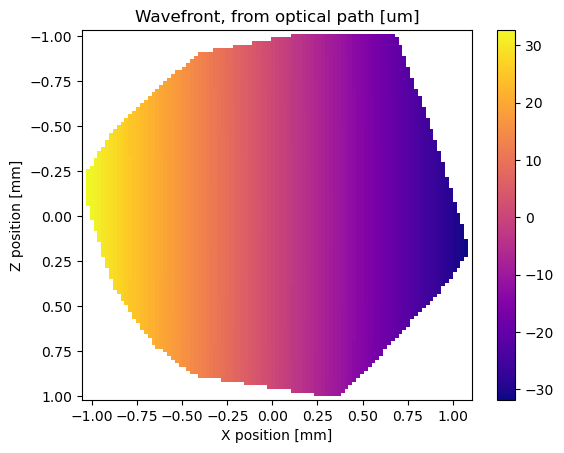

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as interpolate
    
Nx=101 
Nz=101

# get the rays and their optical path
x1 = beam.get_column(1)
z1 = beam.get_column(3)
path1 = beam.get_column(13)

# resampling the OPD on a constant grid
x_lin = np.linspace(np.min(x1), np.max(x1), Nx)
z_lin = np.linspace(np.min(z1), np.max(z1), Nx)
X, Z = np.meshgrid(x_lin,z_lin)
wfe1 = interpolate.griddata((x1,z1),path1,(X,Z),method='linear')

#removal pf piston
wfe_um = (wfe1-np.nanmean(wfe1))*1e6

# scale factor for plotting display
scalefactor = 1E3
plt.imshow(wfe_um,extent=(X[0,0]*scalefactor,X[0,-1]*scalefactor,Z[-1,0]*scalefactor,Z[0,0]*scalefactor))
plt.title("Wavefront, from optical path [um]")
plt.xlabel("X position [mm]")
plt.ylabel("Z position [mm]")
plt.colorbar()
plt.set_cmap('plasma')
plt.show()

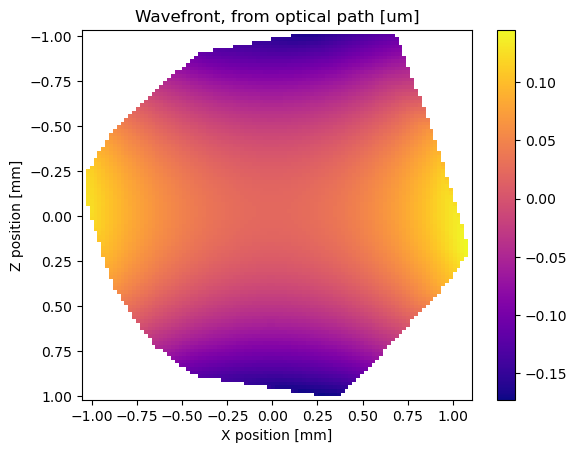

In [21]:
# Flatten arrays and remove NaNs for fitting
X_flat = X.flatten()
Z_flat = Z.flatten()
W_flat = wfe_um.flatten()
mask = ~np.isnan(W_flat)

# Create design matrix for linear fit: W = a*X + b*Z + c
A = np.column_stack([X_flat[mask], Z_flat[mask], np.ones(np.sum(mask))])
coeffs, _, _, _ = np.linalg.lstsq(A, W_flat[mask], rcond=None)

# Calculate the linear trend surface
trend = coeffs[0] * X + coeffs[1] * Z + coeffs[2]

# Remove the trend from the wavefront
wfe_detrend_um = wfe_um - trend

# scale factor for plotting display
scalefactor = 1E3
plt.imshow(wfe_detrend_um,extent=(X[0,0]*scalefactor,X[0,-1]*scalefactor,Z[-1,0]*scalefactor,Z[0,0]*scalefactor))
plt.title("Wavefront, from optical path [um]")
plt.xlabel("X position [mm]")
plt.ylabel("Z position [mm]")
plt.colorbar()
plt.set_cmap('plasma')
plt.show()


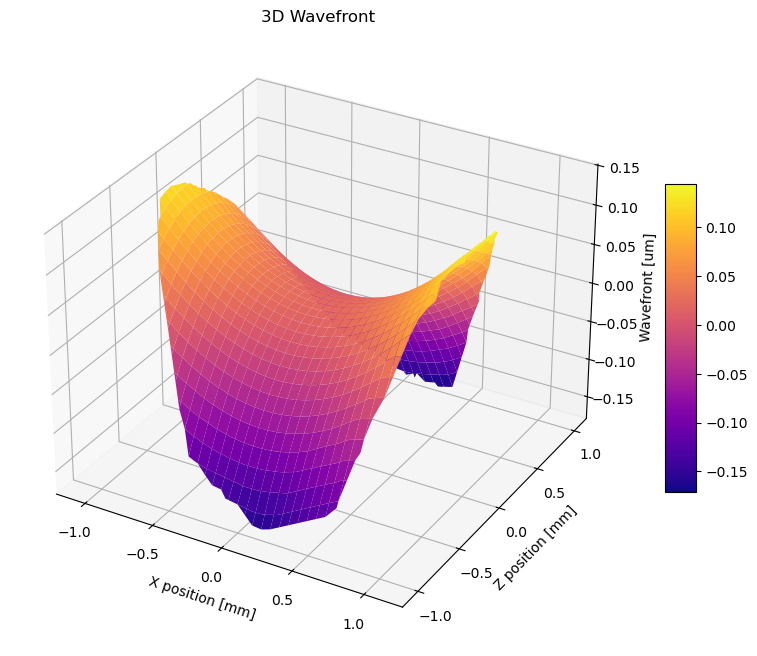

In [22]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
# X and Z are scaled by scalefactor to convert meters to millimeters
surf = ax.plot_surface(X * scalefactor, Z * scalefactor, wfe_detrend_um, cmap='plasma', antialiased=True)

ax.set_title("3D Wavefront")
ax.set_xlabel("X position [mm]")
ax.set_ylabel("Z position [mm]")
ax.set_zlabel("Wavefront [um]")

# Add a colorbar
fig.colorbar(surf, shrink=0.5, aspect=10)

plt.show()



In [23]:
import plotly.graph_objects as go

# Create an interactive 3D surface plot using plotly
fig_interactive = go.Figure(data=[go.Surface(
    z=wfe_detrend_um, 
    x=X * scalefactor, 
    y=Z * scalefactor, 
    colorscale='Plasma'
)])

fig_interactive.update_layout(
    title='3D Wavefront (Interactive)',
    scene=dict(
        xaxis_title='X position [mm]',
        yaxis_title='Z position [mm]',
        zaxis_title='Wavefront [um]'
    ),
    autosize=False,
    width=800,
    height=800,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig_interactive.show()

## Hartmann

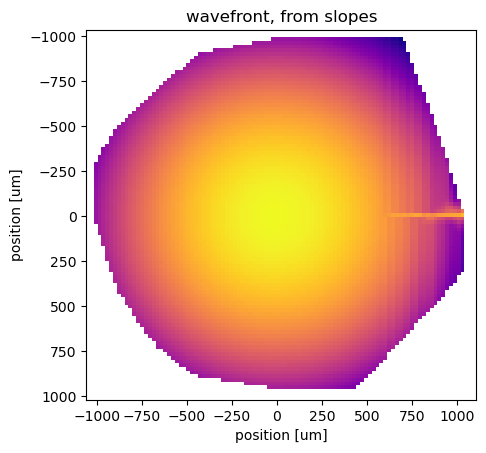

In [ ]:

Nx = 101
Nz = 101
# extract data (position and angles)
x1 = beam.get_column(1)
z1 = beam.get_column(3)
xp = beam.get_column(4)
zp = beam.get_column(6)

# from the angles, extract magnitude and direction
slo = np.sqrt(xp**2+zp**2)
ang = np.arctan2(zp,xp)

# interpolare on a linear grid to allow easier processing
scalefactor = 1E6

x_lin = np.linspace(np.min(x1), np.max(x1), Nx)
z_lin = np.linspace(np.min(z1), np.max(z1), Nx)
X, Z = np.meshgrid(x_lin,z_lin)
slopes = interpolate.griddata((x1,z1),slo,(X,Z),method='linear')
angles = interpolate.griddata((x1,z1),ang,(X,Z),method='linear')
# Fill NaNs to prevent the integration (cumsum) from breaking
slopes = np.nan_to_num(slopes)
angles = np.nan_to_num(angles)
# compute the gradients
grad_x = slopes*np.cos(angles)
grad_z = slopes*np.sin(angles)

# integrate the gradients (from the center) to get the wavefront
xr = np.cumsum(-grad_x[:,51: 0:-1],axis=1)
xl = np.cumsum( grad_x[:,50:-1: 1],axis=1)
xx = np.concatenate((np.flip(xr,axis=1),xl),axis=1)

zr = np.cumsum(-grad_z[51: 0:-1,:],axis=0)
zl = np.cumsum( grad_z[50:-1: 1,:],axis=0)
zz = np.concatenate((np.flip(zr,axis=0),zl),axis=0)

# here's the wavefront (the units depend of the backprogation distance)
wfe_au = (xx+zz)

# show the results
plt.imshow(wfe_au,extent=(X[0,0]*scalefactor,X[0,-1]*scalefactor,Z[-1,0]*scalefactor,Z[0,0]*scalefactor))
plt.title("wavefront, from slopes")
plt.xlabel('position [um]')
plt.ylabel('position [um]')
plt.show()
